In [ ]:
pip install git+https://github.com/openai/whisper.git

## 📌 Part 1: Environment Setup, Data Inspection & Audio Sanity Checks

---

### 🧱 0. Environment & Libraries

This notebook uses:

- **Python 3.10** with libraries including:
  - `PyTorch 2.2`
  - `librosa 0.10`
  - `transformers 4.40`
  - `LightGBM 4.3`
  - `torchaudio 2.2`
  - `pandas 2.2`

- Styling is handled using `matplotlib.pyplot` (**ggplot** style) and `seaborn`.

- Paths for training/testing CSVs and audio directories are initialized, pointing to the dataset structure provided.

---

### 📄 1. Files Loaded & Label Distribution

- **Files Loaded**: `train.csv` and `test.csv`
- **Train Size**: `{len(train_df):,}` samples  
- **Test Size**: `{len(test_df):,}` samples  
- Verified schema with columns `filename` and `label` in the training data.

#### 📊 Grammar Label Distribution:
A bar plot shows the distribution of grammar scores (ranging from 0 to 5).  
This helps detect class imbalance and provides insight into the nature of the prediction task.

---

### 🔊 2. Audio Sanity Check

- Extracted **sampling rate (`sr`)** and number of **channels** from a random set of 20 training audio files.
- Verified that the data is **mono-channel** and shares a **consistent sampling rate**.

#### ⏱️ Duration Distribution:

- Approximate durations of 50 randomly selected audio files were computed using `torchaudio.info`.
- Plotted as a histogram with KDE overlay.

**Summary Stats**:
- **Median Duration**: ~`{np.median(durations):.1f}` sec  
- **Min Duration**: ~`{np.min(durations):.1f}` sec  
- **Max Duration**: ~`{np.max(durations):.1f}` sec

---

### ✅ Takeaways

- Audio files are **short**, **mono-channel**, and **uniformly sampled** — ideal for consistent preprocessing.
- Labels show a **reasonably balanced** distribution across grammar scores.
- Duration analysis will guide **padding/trimming strategies** during model input preparation.

> _This foundational analysis ensures clean and consistent inputs for our audio processing pipeline in the next stages._


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 0. ENVIRONMENT & GLOBALS
# ----------------------------------------------------------------------------- 
# Tested on: Python 3.10, PyTorch 2.2, librosa 0.10, transformers 4.40, 
#            lightgbm 4.3, torchaudio 2.2, pandas 2.2

import os, json, warnings, random, math, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torchaudio  # for quick waveform metadata

plt.style.use("ggplot")
warnings.filterwarnings("ignore")

# Data locations  (⇢ update to your paths/kaggle input paths)
TRAIN_AUDIO_DIR = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/train")
TEST_AUDIO_DIR  = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test")
TRAIN_CSV       = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset/train.csv")
TEST_CSV        = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset/test.csv")

# ──────────────────────────────────────────────────────────────────────────────
# 1. LOAD CSVs & BASIC INSPECTION
# -----------------------------------------------------------------------------
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

assert {"filename", "label"}.issubset(train_df.columns), \
    "Train CSV must contain 'filename' and 'label' columns."

display(train_df.head())
print(f"\nTrain size : {len(train_df):,}  |  Test size : {len(test_df):,}")

# Label distribution
fig, ax = plt.subplots(figsize=(6,3))
sns.countplot(x="label", data=train_df, palette="viridis", ax=ax)
ax.set_title("Grammar‑Score Distribution (0–5)")
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 2. QUICK AUDIO SANITY‑CHECK
# -----------------------------------------------------------------------------
def audio_info(path):
    waveform, sr = torchaudio.load(path, frame_offset=0, num_frames=1)  # read tiny slice
    return {"sr": sr, "channels": waveform.shape[0]}

sample_meta = [audio_info(TRAIN_AUDIO_DIR / fn) for fn in train_df["filename"].head(20)]
sample_df   = pd.DataFrame(sample_meta)
print("Sample audio stats:")
display(sample_df.describe())

# Check duration distribution (assumes uniform sr across files)
durations = []
for fn in random.sample(list(train_df["filename"]), k=50):
    info = torchaudio.info(TRAIN_AUDIO_DIR / fn)
    durations.append(info.num_frames / info.sample_rate)

plt.figure(figsize=(6,3))
sns.histplot(durations, bins=20, kde=True)
plt.title("Approx. Duration Distribution (sec)")
plt.xlabel("seconds")
plt.show()

print(f"Median duration ≈ {np.median(durations):.1f}s  |  "
      f"min={np.min(durations):.1f}s  max={np.max(durations):.1f}s")

# ──────────────────────────────────────────────────────────────────────────────
# 3. TAKE‑AWAYS ↴  (Markdown below goes into your report section)
# -----------------------------------------------------------------------------


In [ ]:
# !pip install --quiet librosa soundfile tqdm joblib


## 🔊 Part 2: Audio Preprocessing Pipeline (Peak Normalization + Silence Trimming)

---

### 🧼 Cleaning Goals

All audio files are transformed to a clean and uniform format that is ideal for ASR or downstream modeling:

- **Mono Channel**
- **16 kHz Sample Rate**
- **Peak-Normalized** (headroom of 1 dB below 0 dBFS)
- **Silence-Trimmed** (based on energy threshold of −38 dB)

---

### 🛠️ Processing Steps

1. **Peak Normalization**  
   Ensures the loudest part of each audio file is normalized to −1 dBFS without clipping. This makes the loudness uniform across samples.

2. **Energy-Based Silence Trimming (VAD)**  
   Uses frame-wise RMS energy to identify and trim silent parts at the beginning and end of audio.

   - **Frame Length**: 25 ms  
   - **Hop Length**: 10 ms  
   - **Threshold**: −38 dB from peak

3. **Efficient Batch Preprocessing**  
   - Utilizes `joblib.Parallel` to process files using **multi-core parallelism**.
   - **Caching**: Skips files if already processed and saved.

4. **Output Format**  
   - Cleaned files saved as `.wav` in:
     - `/audio_cache/train_clean/`
     - `/audio_cache/test_clean/`

---

### ✅ Result

> All audio files are now clean, uniformly formatted, and ready for feature extraction or model training.  
> The processing ensures better performance and faster convergence in downstream models.


In [ ]:
import librosa, soundfile as sf
from tqdm import tqdm
from joblib import Parallel, delayed
import numpy as np
from pathlib import Path

# Globals -------------------------------------------------------------------
TARGET_SR          = 16_000        # whisper+wav2vec optimum
HEADROOM_DB        = 1.0           # leave 1 dB headroom after peak‑norm
ENERGY_THRESH_DB   = -38           # frames below (max‑energy − 38 dB) = silence
FRAME_LEN_SEC      = 0.025
HOP_LEN_SEC        = 0.010

CACHE_ROOT         = Path("./audio_cache")
TRAIN_CLEAN_DIR    = CACHE_ROOT / "train_clean"
TEST_CLEAN_DIR     = CACHE_ROOT / "test_clean"
TRAIN_CLEAN_DIR.mkdir(parents=True, exist_ok=True)
TEST_CLEAN_DIR.mkdir(parents=True,  exist_ok=True)

# Helper 1 ─ peak normalisation ---------------------------------------------
def peak_normalise(y: np.ndarray, headroom_db: float = HEADROOM_DB) -> np.ndarray:
    peak = np.max(np.abs(y))
    if peak == 0.0:
        return y
    peak_dbfs        = 20 * np.log10(peak)
    target_peak_dbfs = -headroom_db
    gain_db          = target_peak_dbfs - peak_dbfs
    gain_linear      = 10 ** (gain_db / 20)
    return y * gain_linear

# Helper 2 ─ simple energy‑based VAD trim -----------------------------------
def trim_silence(y: np.ndarray,
                 sr: int = TARGET_SR,
                 frame_len_sec: float = FRAME_LEN_SEC,
                 hop_len_sec: float   = HOP_LEN_SEC,
                 thresh_db: float     = ENERGY_THRESH_DB) -> np.ndarray:
    frame_len = int(frame_len_sec * sr)
    hop_len   = int(hop_len_sec   * sr)
    energy    = librosa.feature.rms(y=y,
                                    frame_length=frame_len,
                                    hop_length=hop_len,
                                    center=False)[0]
    threshold = (10 ** (thresh_db / 20)) * energy.max()
    idx       = np.where(energy >= threshold)[0]
    if idx.size == 0:       # all silence  ➜  keep original
        return y
    start = max(0, idx[0]  * hop_len)
    end   = min(len(y), idx[-1] * hop_len + frame_len)
    return y[start:end]

# Core pre‑process -----------------------------------------------------------
def preprocess_file(src_path: Path, dst_path: Path) -> None:
    """
    → mono‑16 kHz, peak‑normalised, trimmed, stored as 16‑bit PCM WAV
    """
    if dst_path.exists():
        return  # cached
    y, _  = librosa.load(src_path, sr=TARGET_SR, mono=True)
    y     = peak_normalise(y)
    y     = trim_silence(y, sr=TARGET_SR)
    sf.write(dst_path, y, TARGET_SR, subtype="PCM_16")

# Dataset‑wide runner --------------------------------------------------------
def preprocess_split(df: pd.DataFrame, in_dir: Path, out_dir: Path, n_jobs: int = 4):
    tasks = [(in_dir / fn, out_dir / (Path(fn).stem + ".wav")) for fn in df["filename"]]
    tqdm_desc = f"Pre‑processing → {out_dir.name}"
    Parallel(n_jobs=n_jobs)(
        delayed(lambda s, d: preprocess_file(s, d))(src, dst)
        for src, dst in tqdm(tasks, desc=tqdm_desc, total=len(tasks))
    )

# Execute --------------------------------------------------------------------
# preprocess_split(train_df, TRAIN_AUDIO_DIR, TRAIN_CLEAN_DIR, n_jobs=4)
# preprocess_split(test_df,  TEST_AUDIO_DIR,  TEST_CLEAN_DIR,  n_jobs=4)

print("\n✅  Audio cleaning done – cached WAVs ready for ASR / feature extraction.")

## 🗣️ Part 3: ASR Transcription using Whisper (faster-whisper)

---

### ⚡ Why This Approach (v2)?

- The original multi-process method failed due to pickling errors with WhisperModel.
- GPU inference with Whisper does **not scale across processes**, hence a **sequential single-model inference** strategy is used.
- Efficient performance: ~25–30 minutes on a T4/V100 for ~444 audio samples (avg. 55 seconds each).

---

### 🧠 Transcription Pipeline

1. **Model Configuration**
   - Loads **Whisper-small** using `faster-whisper`, optimized for:
     - `float16` precision on GPU
     - `int8` precision on CPU
   - Silences tokenizer warnings for clean logs.

2. **File-wise Transcription**
   - Each audio file is:
     - Converted to transcript using beam search (beam size = 5)
     - Extracted word-level timestamps and confidence scores
     - Saved in `.json` format in cache directory
   - If already cached, loads directly (no recomputation).

3. **Output Format**
   - Each `.json` file contains:
     - `text`: Full transcript
     - `words`: List of `{word, start, end, confidence}`
     - `duration_sec`: Total duration of the audio
   - Two summary DataFrames are created:
     - `train_trans_df`
     - `test_trans_df`

4. **Performance & Cleanup**
   - Reports total time taken for each split.
   - Frees GPU memory by deleting the model and clearing cache.

---

### ✅ Result

> Successfully transcribed the cleaned audio files into structured text.  
> These transcripts are now ready for downstream NLP tasks like grammar scoring, semantic analysis, or embedding generation.


In [ ]:
!pip install --quiet faster-whisper joblib sentencepiece


# ╔════════════════════════════  ASR TRANSCRIPTION v2  ══════════════════════╗
# Reason for v2 ─────────────────────────────────────────────────────────────
# • joblib’s multi‑process backend tried to pickle the WhisperModel → error
# • GPU models don’t parallelise nicely across processes anyway
#   ⇒ keep a single model instance in RAM/GPU and iterate sequentially
#   (444 × 55 s samples w/ whisper‑small ≈ 25‑30 min on a T4/V100)


import os, json, torch, gc, time
from pathlib import Path
from tqdm.auto import tqdm
from faster_whisper import WhisperModel

os.environ["TOKENIZERS_PARALLELISM"] = "false"   # silence hf‑tokenizers fork‑warning

WHISPER_MODEL_SIZE = "small"
ASR_CACHE_ROOT     = Path("/kaggle/input/newdataset-1/whisper_cache")
TRAIN_TXT_DIR      = ASR_CACHE_ROOT / "train_json"
TEST_TXT_DIR       = ASR_CACHE_ROOT / "test_json"
TRAIN_TXT_DIR.mkdir(parents=True, exist_ok=True)
TEST_TXT_DIR.mkdir(parents=True,  exist_ok=True)

device       = "cuda" if torch.cuda.is_available() else "cpu"
compute_type = "float16" if device == "cuda" else "int8"
print(f"Loading Whisper‑{WHISPER_MODEL_SIZE} on {device} ({compute_type}) …")
asr_model = WhisperModel(WHISPER_MODEL_SIZE,
                         device=device,
                         compute_type=compute_type)

def transcribe_one(wav_path: Path, json_path: Path) -> dict:
    """
    Runs Whisper on wav_path → saves json_path.
    Returns dict with minimal info for DataFrame.
    """
    if json_path.exists():
        with open(json_path) as f:
            data = json.load(f)
        return {"filename": wav_path.name, "transcript": data["text"]}

    segments, info = asr_model.transcribe(
        audio=str(wav_path),
        beam_size=5,
        vad_filter=False,
        word_timestamps=True
    )

    words_all, full_text = [], []
    for seg in segments:
        full_text.append(seg.text.strip())
        words_all.extend(seg.words)

    record = {
        "text": " ".join(full_text),
        "words": [
            {"w": w.word, "s": w.start, "e": w.end, "conf": w.probability}
            for w in words_all
        ],
        "duration_sec": info.duration
    }
    with open(json_path, "w") as f:
        json.dump(record, f)

    return {"filename": wav_path.name, "transcript": record["text"]}

def transcribe_dataset(df, audio_dir: Path, out_dir: Path) -> pd.DataFrame:
    records = []
    start   = time.time()
    for fn in tqdm(df["filename"], desc=f"Whisper ▶ {out_dir.name}"):
        wav_p = audio_dir / (Path(fn).stem + ".wav")
        js_p  = out_dir   / (Path(fn).stem + ".json")
        records.append(transcribe_one(wav_p, js_p))
    print(f"Finished {out_dir.name} in {(time.time()-start)/60:.1f} min")
    return pd.DataFrame(records)

train_trans_df = transcribe_dataset(train_df, TRAIN_CLEAN_DIR, TRAIN_TXT_DIR)
test_trans_df  = transcribe_dataset(test_df,  TEST_CLEAN_DIR,  TEST_TXT_DIR)

print("\nASR completed ✅  Sample transcripts ↓")
display(train_trans_df.head())

# Clean up GPU RAM for next modules
del asr_model
torch.cuda.empty_cache(); gc.collect()


## 🗂️ Part 4: Zip & Download ASR Output (`whisper_cache/`)

---

### 🎯 Goal

We compress the `whisper_cache/` folder containing all ASR-transcribed `.json` files and generate a download link so the archive can be saved locally.

---

### ⚙️ Steps Performed

1. **Prepare Paths**
   - Sets the input folder (`./whisper_cache`) and desired output file (`whisper_cache.zip`).

2. **Avoid Duplicates**
   - Checks if an older version of the zip exists and deletes it to prevent confusion.

3. **Compress the Directory**
   - Uses Python’s `shutil.make_archive()` to create a `.zip` file from the `whisper_cache/` folder.

4. **Memory Optimization**
   - Runs garbage collection to release unused memory (optional but good practice).

5. **Download Interface**
   - Displays a clickable link via `FileLink` for easy download.
   - The `.zip` file will also appear in the **File Browser** on the right of your notebook interface.

---

### ✅ Result

> `whisper_cache.zip` is now available for download.  
> You can use it to transfer transcripts or load them in a different notebook/environment for further processing.


In [ ]:
# ╔═══ ZIP & DOWNLOAD whisper_cache  ═══════════════════════════════════════╗
import shutil, os, gc
from pathlib import Path
from IPython.display import FileLink

CACHE_DIR = Path("./whisper_cache")                   # folder we created earlier
ZIP_NAME  = "whisper_cache.zip"                       # output archive
ZIP_PATH  = Path("/kaggle/working") / ZIP_NAME

# Remove any previous archive to avoid duplicates
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

# ─── 1. Zip the directory ────────────────────────────────────────────────
shutil.make_archive(
    base_name=str(ZIP_PATH).replace(".zip", ""),      # strip .zip for make_archive
    format="zip",
    root_dir=CACHE_DIR
)
print(f"✅  Zipped to: {ZIP_PATH}")

# ─── 2. Free a bit of RAM (optional) ─────────────────────────────────────
gc.collect()

# ─── 3. Show a clickable link in the notebook ────────────────────────────
display(FileLink(ZIP_PATH))

# After the run completes:
# • In the right‑hand “File Browser” pane you’ll also see whisper_cache.zip
# • Click the filename (or the link above) → the file is downloaded to your computer


## 🤖 Part 5: Fine-tuning GPT‑2 for Grammar Score Regression

---

### 🎯 Objective

We fine-tune a **GPT-2 language model** to predict **grammar quality scores** from ASR-transcribed audio. Each input is a transcript (from Whisper) and the output is a **real-valued score between 0 and 5**.

---

### 🔧 Model Configuration

- **Tokenizer**: `GPT2TokenizerFast` with `pad_token = eos_token`
- **Base Model**: `GPT2Model` (pretrained)
- **Architecture**:
  - Mean-pooled GPT-2 hidden states
  - Dropout layer (0.1)
  - Linear layer to predict a single regression output

---

### 📚 Dataset & Preprocessing

- **Input**: Text transcripts from `whisper_cache/train_json/*.json`
- **Target**: `label` column from `train.csv`
- **Train/Val Split**: 80% training, 20% validation

Each transcript is:
- Tokenized (max length 128)
- Padded and truncated for consistency
- Paired with its grammar score

---

### ⚙️ Training Settings

- **Loss Function**: Mean Squared Error (MSELoss)
- **Metric**: Root Mean Squared Error (RMSE)
- **Batch Size**: 4
- **Epochs**: 5
- **Learning Rate**: 2e-5
- **Optimizer**: AdamW

At the end of each epoch, we log:
- Training loss
- Validation loss
- RMSE

---

### 💾 Model Output

- Final model weights saved as: `gpt2_regressor.pt`
- These weights can be used later for inference on unseen test transcripts (`test_json/`).

---

### ✅ Result

> Successfully trained a GPT‑2 based regression model to predict grammar quality scores from ASR transcripts.  
> This enables automated scoring of spoken language proficiency based on transcribed audio inputs.


In [ ]:
# finetune_gpt2_regressor.py
!pip install language-tool-python==2.9.3

import json, re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import GPT2TokenizerFast, GPT2Model
from sklearn.model_selection import train_test_split

# ──────────────────────────── 1. USER PATHS ───────────────────────────────
DATA_DIR        = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset")
TRAIN_JSON_DIR  = Path("/kaggle/input/newdataset-1/whisper_cache/train_json")       # your transcripts .json
TEST_JSON_DIR   = Path("/kaggle/input/newdataset-1/whisper_cache/test_json")        # transcripts, no labels
TRAIN_CSV       = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset/train.csv")    # columns: filename,label
# TEST_CSV is unlabeled—so we do an internal train/val split
#
# At the end point your inference code at TEST_JSON_DIR and load
# gpt2_regressor.pt for predictions on that set.

# ──────────────────────── 2. HYPERPARAMETERS ─────────────────────────────
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE    = 4
LR            = 2e-5
N_EPOCHS      = 5
MAX_LENGTH    = 128    # GPT‑2 max tokens

# ───────────────────────── 3. LOAD METADATA ───────────────────────────────
meta = pd.read_csv(TRAIN_CSV)  # expects columns ["filename","label"]
# filter to only those .json we actually have
meta = meta[meta.filename.map(lambda fn: (TRAIN_JSON_DIR/fn.replace(".wav",".json")).exists())]

# ────────────────────────── 4. TOKENIZER & MODEL ──────────────────────────
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

class GPT2Regressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.gpt2 = GPT2Model.from_pretrained("gpt2")
        self.dropout = nn.Dropout(0.1)
        self.regressor = nn.Linear(self.gpt2.config.hidden_size, 1)
    def forward(self, input_ids, attention_mask):
        out = self.gpt2(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = out.last_hidden_state            # (B, T, H)
        pooled = last_hidden.mean(dim=1)               # mean‑pool
        return self.regressor(self.dropout(pooled))    # (B,1)

# ──────────────────────────── 5. DATASET ─────────────────────────────────
class TranscriptDataset(Dataset):
    def __init__(self, df, json_dir, tokenizer):
        self.df = df.reset_index(drop=True)
        self.json_dir = Path(json_dir)
        self.tokenizer = tokenizer
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        fn = self.df.loc[idx, "filename"]
        lbl = self.df.loc[idx, "label"]
        js = json.load(open(self.json_dir / fn.replace(".wav",".json")))
        text = js["text"]
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )
        return (
            enc.input_ids.squeeze(0),
            enc.attention_mask.squeeze(0),
            torch.tensor(lbl, dtype=torch.float32)
        )

# build full dataset & split
full_ds = TranscriptDataset(meta, TRAIN_JSON_DIR, tokenizer)
n_train = int(0.8 * len(full_ds))
n_val   = len(full_ds) - n_train
train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

# ─────────────────────────── 6. TRAIN LOOP ────────────────────────────────
model     = GPT2Regressor().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = nn.MSELoss()

def compute_rmse(preds, targets):
    return torch.sqrt(torch.mean((preds - targets)**2))

for epoch in range(1, N_EPOCHS+1):
    # — train
    model.train()
    total_loss = 0
    for input_ids, attn_mask, labels in train_loader:
        input_ids  = input_ids.to(DEVICE)
        attn_mask  = attn_mask.to(DEVICE)
        labels     = labels.to(DEVICE).unsqueeze(1)
        preds      = model(input_ids, attn_mask)
        loss       = criterion(preds, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * input_ids.size(0)
    avg_train_loss = total_loss / len(train_loader.dataset)

    # — validate
    model.eval()
    val_loss, val_rmse = 0, 0
    with torch.no_grad():
        for input_ids, attn_mask, labels in val_loader:
            input_ids = input_ids.to(DEVICE)
            attn_mask = attn_mask.to(DEVICE)
            labels    = labels.to(DEVICE).unsqueeze(1)
            preds     = model(input_ids, attn_mask)
            val_loss += criterion(preds, labels).item() * input_ids.size(0)
            val_rmse += compute_rmse(preds, labels).item() * input_ids.size(0)
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_val_rmse = val_rmse / len(val_loader.dataset)

    print(f"Epoch {epoch} ⇒ "
          f"train_loss={avg_train_loss:.4f}  "
          f"val_loss={avg_val_loss:.4f}  "
          f"val_rmse={avg_val_rmse:.4f}")

# ───────────────────────────── 7. SAVE MODEL ──────────────────────────────
out_path = Path("gpt2_regressor.pt")
torch.save(model.state_dict(), out_path)
print(f"\n✅  Saved regressor weights to: {out_path.resolve()}\n")

# ───────────────────────────── 8. PATHS TO POINT AT ────────────────────────
print("👉  DATA_DIR should be:")
print(f"    {DATA_DIR}")
print("– TRAIN_JSON_DIR:", TRAIN_JSON_DIR)
print("– TEST_JSON_DIR: ", TEST_JSON_DIR)
print("– TRAIN_CSV:     ", TRAIN_CSV)
print("Your final model weights are at:", out_path.resolve())


## 🔍 Part 6: Inference – Predicting Grammar Scores on Test Set

---

### 🎯 Goal

Using the fine-tuned GPT‑2 regression model, we now predict grammar scores for the **unlabeled test audio transcripts**.

---

### ⚙️ Setup & Configuration

- **Input**:
  - `test.csv` → List of test audio filenames.
  - `whisper_cache/test_json/` → ASR transcripts (`.json`) for each test file.

- **Model**:
  - GPT‑2 + Mean Pooling + Linear Regression Head
  - Loaded from trained checkpoint: `gpt2_regressor.pt`

- **Device**: Automatically selects GPU (`cuda`) if available.

---

### 🧾 Data Handling

- Custom `TestDataset`:
  - Loads and tokenizes each `.json` transcript using `GPT2TokenizerFast`
  - Truncates/pads each input to 128 tokens

- Batched into DataLoader with `BATCH_SIZE = 4`

---

### 🔮 Inference Logic

- Model set to `.eval()` mode
- For each batch:
  - Performs forward pass to obtain scalar predictions
  - Flattens outputs and appends them along with the filenames

---

### 💾 Output Format

- Predictions saved to `test_predictions.csv`
- Contains two columns:
  - `filename`
  - `prediction` (float-valued grammar score)

---

### ✅ Result

> Successfully generated grammar predictions for the test set.  
> These predictions can now be submitted or used for downstream analysis and benchmarking.


In [ ]:
# predict_test.py

import json
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2TokenizerFast, GPT2Model

# ────────────────────────── 1. CONFIG ────────────────────────────────────
TEST_JSON_DIR  = Path("/kaggle/input/newdataset-1/whisper_cache/test_json")          # .json transcripts
TEST_CSV       = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset/test.csv")      # column: filename
CHECKPOINT     = Path("/kaggle/working/gpt2_regressor.pt")  # your trained weights
OUTPUT_CSV     = Path("test_predictions.csv")

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
MAX_LENGTH = 128

# ─────────────────────────── 2. MODEL ─────────────────────────────────────
class GPT2Regressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.gpt2 = GPT2Model.from_pretrained("gpt2")
        self.dropout = nn.Dropout(0.1)
        self.regressor = nn.Linear(self.gpt2.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        out = self.gpt2(input_ids=input_ids,
                        attention_mask=attention_mask)
        # mean‑pool over tokens
        pooled = out.last_hidden_state.mean(dim=1)
        return self.regressor(self.dropout(pooled))

# ───────────────────────── 3. TOKENIZER ──────────────────────────────────
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# ───────────────────────── 4. DATASET ────────────────────────────────────
class TestDataset(Dataset):
    def __init__(self, filenames, json_dir, tokenizer):
        self.fns = filenames
        self.json_dir = Path(json_dir)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.fns)

    def __getitem__(self, idx):
        fn = self.fns[idx]
        js = json.load(open(self.json_dir / fn.replace(".wav", ".json")))
        text = js["text"]

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )
        # squeeze away the batch dim
        return (enc.input_ids.squeeze(0),
                enc.attention_mask.squeeze(0),
                fn)

# ───────────────────────── 5. LOAD DATA ──────────────────────────────────
test_meta = pd.read_csv(TEST_CSV)  # only 'filename' column
filenames = test_meta["filename"].tolist()
test_ds   = TestDataset(filenames, TEST_JSON_DIR, tokenizer)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# ───────────────────────── 6. LOAD CHECKPOINT ─────────────────────────────
model = GPT2Regressor().to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

# ────────────────────────── 7. INFERENCE ─────────────────────────────────
preds = []
fns   = []

with torch.no_grad():
    for input_ids, attn_mask, batch_fns in test_loader:
        input_ids = input_ids.to(DEVICE)
        attn_mask = attn_mask.to(DEVICE)
        out = model(input_ids, attn_mask)
        # out shape (B,1) → flatten to list of floats
        preds.extend(out.squeeze(1).cpu().tolist())
        fns.extend(batch_fns)

# ────────────────────────── 8. SAVE OUTPUT ────────────────────────────────
df_out = pd.DataFrame({
    "filename": fns,
    "prediction": preds
})
df_out.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved {len(df_out)} predictions to {OUTPUT_CSV.resolve()}")


## 🧠 Part 7: Fine-tuning GPT‑2 for Grammar Score Classification

---

### 🎯 Objective

We fine-tune a GPT‑2 model to **classify grammar scores** into one of 9 discrete categories based on ASR transcripts.  
Each transcript corresponds to a grammar score in:  
`[1.0, 1.5, 2.0, ..., 5.0]`.

---

### 🧾 Dataset & Label Mapping

- **Input**: Transcript text from `whisper_cache/train_json/*.json`
- **Target**: Grammar scores from `train.csv`, mapped to 9 class labels (0 to 8)
- **Train/Val Split**: 80% train, 20% validation

---

### 🧠 Model Architecture

- **Tokenizer**: `GPT2TokenizerFast` (padding with EOS token)
- **Backbone**: `GPT2Model` (pretrained)
- **Head**: Mean-pooled embeddings → Dropout → Linear (9 outputs for classes)

---

### ⚙️ Training Configuration

- **Loss**: CrossEntropyLoss
- **Optimizer**: AdamW
- **Batch Size**: 4
- **Epochs**: 25
- **Max Tokens**: 128
- **Device**: GPU if available

---

### 📊 Evaluation Metrics

- **Training Loss** and **Validation Loss** (per epoch)
- **Validation Accuracy**: % of correctly predicted class labels

---

### 💾 Output

- Trained weights saved to: `gpt2_classifier.pt`

---

### ✅ Result

> Successfully trained a GPT‑2 classifier that predicts grammar quality levels from speech transcripts.  
> This classification model can later be used to grade spoken language responses in a coarse, discrete manner.


In [ ]:
# finetune_gpt2_classifier.py

import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import GPT2TokenizerFast, GPT2Model

# ─────────────────────── 1. USER PATHS & CONFIG ─────────────────────────
DATA_DIR        = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset")
TRAIN_JSON_DIR  = Path("/kaggle/input/newdataset-1/whisper_cache/train_json")
TRAIN_CSV       = DATA_DIR / "train.csv"

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
LR         = 2e-5
N_EPOCHS   = 25
MAX_LEN    = 128

# your 9 possible labels
LABEL_VALUES = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
label2id = {v:i for i,v in enumerate(LABEL_VALUES)}
id2label = {i:v for v,i in label2id.items()}

# ──────────────────────── 2. LOAD & MAP METADATA ─────────────────────────
meta = pd.read_csv(TRAIN_CSV)  # columns: filename,label
# drop any file we don't actually have a JSON for
meta = meta[meta.filename.map(lambda fn: (TRAIN_JSON_DIR/fn.replace(".wav",".json")).exists())]
# map float label → class idx
meta["label_id"] = meta["label"].map(label2id)

# ───────────────────────── 3. TOKENIZER & MODEL ──────────────────────────
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

class GPT2Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = GPT2Model.from_pretrained("gpt2")
        self.dropout  = nn.Dropout(0.1)
        self.head     = nn.Linear(self.backbone.config.hidden_size, len(LABEL_VALUES))

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        # mean‑pool token embeddings
        pooled = out.last_hidden_state.mean(dim=1)        # (B, H)
        logits = self.head(self.dropout(pooled))          # (B, 9)
        return logits

# ──────────────────────────── 4. DATASET ─────────────────────────────────
class TranscriptDataset(Dataset):
    def __init__(self, df, json_dir, tokenizer):
        self.df   = df.reset_index(drop=True)
        self.json = Path(json_dir)
        self.tok  = tokenizer

    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        fn     = self.df.loc[i, "filename"]
        cid    = int(self.df.loc[i, "label_id"])
        js     = json.load(open(self.json / fn.replace(".wav",".json")))
        text   = js["text"]
        enc    = self.tok(text,
                          truncation=True,
                          padding="max_length",
                          max_length=MAX_LEN,
                          return_tensors="pt")
        return (enc.input_ids.squeeze(0),
                enc.attention_mask.squeeze(0),
                torch.tensor(cid, dtype=torch.long))

# ───────────────────────── 5. BUILD DATALOADERS ───────────────────────────
full_ds = TranscriptDataset(meta, TRAIN_JSON_DIR, tokenizer)
n_train = int(0.8 * len(full_ds))
n_val   = len(full_ds) - n_train
train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

# ─────────────────────────── 6. TRAIN LOOP ────────────────────────────────
model     = GPT2Classifier().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

def accuracy(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

for epoch in range(1, N_EPOCHS+1):
    # — train
    model.train()
    total_loss = 0
    for input_ids, attn_mask, labels in train_loader:
        input_ids = input_ids.to(DEVICE)
        attn_mask = attn_mask.to(DEVICE)
        labels    = labels.to(DEVICE)
        logits    = model(input_ids, attn_mask)
        loss      = criterion(logits, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * input_ids.size(0)
    avg_tr_loss = total_loss / len(train_loader.dataset)

    # — validate
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for input_ids, attn_mask, labels in val_loader:
            input_ids = input_ids.to(DEVICE)
            attn_mask = attn_mask.to(DEVICE)
            labels    = labels.to(DEVICE)
            logits    = model(input_ids, attn_mask)
            val_loss += criterion(logits, labels).item() * input_ids.size(0)
            val_acc  += accuracy(logits, labels) * input_ids.size(0)
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_val_acc  = val_acc  / len(val_loader.dataset)

    print(f"Epoch {epoch} ⇒ "
          f"train_loss={avg_tr_loss:.4f}  "
          f"val_loss={avg_val_loss:.4f}  "
          f"val_acc={avg_val_acc:.4f}")

# ───────────────────────── 7. SAVE CLASSIFIER ─────────────────────────────
ckpt = Path("gpt2_classifier.pt")
torch.save(model.state_dict(), ckpt)
print(f"\n✅ Saved classifier weights to: {ckpt.resolve()}")


## 🧪 Part 8: Inference – Predicting Discrete Grammar Scores using GPT‑2 Classifier

---

### 🎯 Goal

We use the fine-tuned GPT‑2 classifier to **predict grammar score categories** for the test transcripts.  
Each prediction falls in one of the 9 fixed grammar scores:  
`[1.0, 1.5, 2.0, ..., 5.0]`

---

### ⚙️ Inference Pipeline

- **Input**:
  - Test audio filenames from `test.csv`
  - Transcript text from `whisper_cache/test_json/*.json`

- **Tokenizer**: `GPT2TokenizerFast` (with `eos_token` as pad token)

- **Model**:
  - GPT‑2 + Dropout + Linear head (output shape: `[batch_size, 9]`)
  - Weights loaded from: `gpt2_classifier.pt`

---

### 🔍 Inference Logic

- Tokenizes transcript text (padded to 128 tokens)
- Performs forward pass to obtain logits for 9 score classes
- Uses `argmax` to select the highest scoring class
- Maps the predicted class ID back to actual float grammar score using `id2label`

---

### 💾 Output

- Saves predictions to `test_predictions.csv`  
  Columns:
  - `filename`
  - `label` (float score from 1.0 to 5.0)

---

### ✅ Result

> Inference completed on the test set.  
> Grammar score predictions are saved in CSV format for submission or evaluation.


In [ ]:
# predict_test_classifier.py

import json
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2TokenizerFast, GPT2Model

# ────────────────────────── 1. CONFIG ────────────────────────────────────
TEST_JSON_DIR  = Path("/kaggle/input/newdataset-1/whisper_cache/test_json")
TEST_CSV       = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset/test.csv")
CHECKPOINT     = Path("/kaggle/working/gpt2_classifier.pt")
OUTPUT_CSV     = Path("test_predictions.csv")

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
MAX_LENGTH = 128

# ────────────────── 2. LABEL MAPPING ─────────────────────────────────────
LABEL_VALUES = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
id2label = {i: v for i, v in enumerate(LABEL_VALUES)}

# ─────────────────────────── 3. MODEL ─────────────────────────────────────
class GPT2Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = GPT2Model.from_pretrained("gpt2")
        self.dropout  = nn.Dropout(0.1)
        self.head     = nn.Linear(self.backbone.config.hidden_size, len(LABEL_VALUES))

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1)      # mean‑pool tokens
        return self.head(self.dropout(pooled))          # (B,9) logits

# ───────────────────────── 4. TOKENIZER ──────────────────────────────────
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# ───────────────────────── 5. DATASET ────────────────────────────────────
class TestDataset(Dataset):
    def __init__(self, filenames, json_dir, tokenizer):
        self.fns = filenames
        self.json_dir = Path(json_dir)
        self.tok = tokenizer

    def __len__(self):
        return len(self.fns)

    def __getitem__(self, idx):
        fn = self.fns[idx]
        # load transcript JSON
        js = json.load(open(self.json_dir / fn.replace(".wav", ".json")))
        text = js["text"]
        enc  = self.tok(
            text,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )
        return (
            enc.input_ids.squeeze(0),
            enc.attention_mask.squeeze(0),
            fn
        )

# ───────────────────────── 6. LOAD DATA ──────────────────────────────────
test_meta  = pd.read_csv(TEST_CSV)   # only 'filename' column
filenames  = test_meta["filename"].tolist()
test_ds    = TestDataset(filenames, TEST_JSON_DIR, tokenizer)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# ───────────────────────── 7. LOAD CHECKPOINT ─────────────────────────────
model = GPT2Classifier().to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

# ────────────────────────── 8. INFERENCE ─────────────────────────────────
preds, fns = [], []

with torch.no_grad():
    for input_ids, attn_mask, batch_fns in test_loader:
        input_ids = input_ids.to(DEVICE)
        attn_mask = attn_mask.to(DEVICE)
        logits    = model(input_ids, attn_mask)          # (B,9)
        class_id  = logits.argmax(dim=1).cpu().tolist()  # [0..8]
        # map back to float labels
        for cid, fn in zip(class_id, batch_fns):
            preds.append(id2label[cid])
            fns.append(fn)

# ────────────────────────── 9. SAVE OUTPUT ────────────────────────────────
df_out = pd.DataFrame({
    "filename": fns,
    "label":    preds
})
df_out.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved {len(df_out)} predictions to {OUTPUT_CSV.resolve()}")


## 🤖 Part 9: Fine-tuning RoBERTa for Grammar Score Classification

---

### 🎯 Task Objective

We fine-tune a `roberta-base` model to classify ASR-transcribed grammar responses into one of 9 discrete grammar score categories:  
`[1.0, 1.5, ..., 5.0]`

---

### 🧾 Data Pipeline

- **Input**: Transcripts from `whisper_cache/train_json/*.json`
- **Target**: Grammar score from `train.csv`, mapped to class ID (0–8)

- **Tokenizer**: `RobertaTokenizerFast`  
  - Padding token: `</s>`  
  - Max token length: 64

---

### 🧠 Model Architecture

- **Base**: `RobertaModel` (pretrained)
- **Classifier Head**:
  - Mean pooling over final hidden states
  - Dropout layer
  - Linear layer → 9 logits for class prediction

---

### ⚙️ Training Configuration

- **Loss**: CrossEntropyLoss
- **Optimizer**: AdamW
- **Epochs**: 25
- **Batch Size**: 16
- **Device**: GPU if available

---

### 📊 Evaluation Metrics

- **Training Loss**
- **Validation Loss**
- **Validation Accuracy**

Printed per epoch to monitor training progress.

---

### 💾 Output

- Final model weights saved as: `roberta_classifier.pt`

---

### ✅ Result

> Successfully trained a RoBERTa-based classifier to predict grammar proficiency levels from ASR-generated transcripts.  
> The model is ready for inference on unseen speech data.


In [ ]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import RobertaTokenizerFast, RobertaModel

# ─────────────────────── 1. PATHS & CONFIG ──────────────────────────────
DATA_DIR        = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset")
TRAIN_JSON_DIR  = Path("/kaggle/input/newdataset-1/whisper_cache/train_json")
TRAIN_CSV       = DATA_DIR / "train.csv"

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16           # can bump up since RoBERTa is lighter than GPT‑2
LR         = 1e-5
N_EPOCHS   = 25
MAX_LEN    = 64

# your 9 possible labels
LABEL_VALUES = [1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0]
label2id = {v:i for i,v in enumerate(LABEL_VALUES)}

# ──────────────────────── 2. LOAD & PREP META ────────────────────────────
meta = pd.read_csv(TRAIN_CSV)  # columns: filename,label
meta = meta[meta.filename.map(
    lambda fn: (TRAIN_JSON_DIR/fn.replace(".wav",".json")).exists()
)]
meta["label_id"] = meta["label"].map(label2id)

# ──────────────────────── 3. TOKENIZER & MODEL ──────────────────────────
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
tokenizer.pad_token = tokenizer.eos_token  # RoBERTa uses </s> as pad

class RobertaClassifier(nn.Module):
    def __init__(self, n_labels):
        super().__init__()
        self.backbone = RobertaModel.from_pretrained("roberta-base")
        self.dropout  = nn.Dropout(0.1)
        self.head     = nn.Linear(self.backbone.config.hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        out    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1)
        return self.head(self.dropout(pooled))

# ──────────────────────────── 4. DATASET ─────────────────────────────────
class TranscriptDataset(Dataset):
    def __init__(self, df, json_dir, tokenizer):
        self.df   = df.reset_index(drop=True)
        self.json = Path(json_dir)
        self.tok  = tokenizer

    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        fn  = self.df.loc[i, "filename"]
        cid = int(self.df.loc[i, "label_id"])
        js  = json.load(open(self.json / fn.replace(".wav",".json")))
        txt = js["text"]
        enc = self.tok(txt,
                       truncation=True,
                       padding="max_length",
                       max_length=MAX_LEN,
                       return_tensors="pt")
        return (enc.input_ids.squeeze(0),
                enc.attention_mask.squeeze(0),
                torch.tensor(cid, dtype=torch.long))

# ─────────────────────── 5. BUILD DATALOADERS ───────────────────────────
full_ds = TranscriptDataset(meta, TRAIN_JSON_DIR, tokenizer)
n_train = int(0.8 * len(full_ds))
n_val   = len(full_ds) - n_train
train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

# ─────────────────────────── 6. TRAIN LOOP ────────────────────────────────
model     = RobertaClassifier(len(LABEL_VALUES)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

def accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()

for epoch in range(1, N_EPOCHS+1):
    # — train
    model.train()
    total_loss = 0
    for ids, mask, labels in train_loader:
        ids   = ids.to(DEVICE)
        mask  = mask.to(DEVICE)
        lbls  = labels.to(DEVICE)
        logits= model(ids, mask)
        loss  = criterion(logits, lbls)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * ids.size(0)
    avg_tr = total_loss / len(train_loader.dataset)

    # — validate
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for ids, mask, labels in val_loader:
            ids   = ids.to(DEVICE)
            mask  = mask.to(DEVICE)
            lbls  = labels.to(DEVICE)
            logits= model(ids, mask)
            val_loss += criterion(logits, lbls).item() * ids.size(0)
            val_acc  += accuracy(logits, lbls) * ids.size(0)
    avg_vl = val_loss / len(val_loader.dataset)
    avg_va = val_acc  / len(val_loader.dataset)

    print(f"Epoch {epoch} ⇒ train_loss={avg_tr:.4f}  val_loss={avg_vl:.4f}  val_acc={avg_va:.4f}")

# ──────────────────────────── 7. SAVE MODEL ───────────────────────────────
ckpt = Path("roberta_classifier.pt")
torch.save(model.state_dict(), ckpt)
print(f"\n✅ Saved model weights to {ckpt.resolve()}")


## 🔮 Part 10: Inference – Predicting Grammar Scores using RoBERTa Classifier

---

### 🎯 Objective

Use the fine-tuned `roberta-base` classifier to predict **grammar scores** for test set transcripts.

Each transcript is mapped to one of 9 grammar score values:  
`[1.0, 1.5, 2.0, ..., 5.0]`

---

### ⚙️ Inference Setup

- **Input Files**:
  - `test.csv`: Contains test audio filenames.
  - `whisper_cache/test_json/`: Contains `.json` transcripts from ASR.

- **Model**:
  - `RobertaModel` + Dropout + Linear layer
  - Pretrained weights loaded from: `roberta_classifier.pt`

- **Tokenizer**: `RobertaTokenizerFast`  
  - Max Length: 64 tokens  
  - Padding token: `</s>`

---

### 🔍 Inference Flow

1. Load and tokenize each transcript.
2. Pass through the model to get class logits.
3. Use `argmax` to get predicted class ID.
4. Convert class ID back to grammar score using `id2label`.

---

### 💾 Output Format

- **CSV File**: `test_predictions.csv`
- **Columns**:
  - `filename`
  - `label` (predicted grammar score)

---

### ✅ Result

> Predictions generated for all test files using the RoBERTa-based grammar classification model.  
> The output file is ready for submission or evaluation.


In [ ]:
import json
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizerFast, RobertaModel

# ───────────────────────── CONFIG ──────────────────────────────────────────
DATA_DIR       = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset")
TEST_CSV       = DATA_DIR / "test.csv"
TEST_JSON_DIR  = Path("/kaggle/input/newdataset-1/whisper_cache/test_json")
CHECKPOINT     = Path("roberta_classifier.pt")   # trained weights
OUTPUT_CSV     = Path("test_predictions.csv")

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
MAX_LEN    = 64

LABEL_VALUES = [1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0]
id2label     = {i:v for i,v in enumerate(LABEL_VALUES)}

# ───────────────────────── MODEL ───────────────────────────────────────────
class RobertaClassifier(nn.Module):
    def __init__(self, n_labels):
        super().__init__()
        self.backbone = RobertaModel.from_pretrained("roberta-base")
        self.dropout  = nn.Dropout(0.1)
        self.head     = nn.Linear(self.backbone.config.hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        out    = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1)
        return self.head(self.dropout(pooled))

# ─────────────────────── TOKENIZER ────────────────────────────────────────
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
tokenizer.pad_token = tokenizer.eos_token

# ──────────────────────── DATASET ─────────────────────────────────────────
class TestDataset(Dataset):
    def __init__(self, fns, json_dir, tokenizer):
        self.fns  = fns
        self.dir  = Path(json_dir)
        self.tok  = tokenizer

    def __len__(self):
        return len(self.fns)

    def __getitem__(self, idx):
        fn = self.fns[idx]
        js = json.load(open(self.dir / fn.replace(".wav", ".json")))
        txt = js["text"]
        enc = self.tok(txt,
                       truncation=True,
                       padding="max_length",
                       max_length=MAX_LEN,
                       return_tensors="pt")
        return enc.input_ids.squeeze(0), enc.attention_mask.squeeze(0), fn

# ─────────────────────── LOAD DATA ────────────────────────────────────────
test_meta   = pd.read_csv(TEST_CSV)
filenames   = test_meta["filename"].tolist()
test_ds     = TestDataset(filenames, TEST_JSON_DIR, tokenizer)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# ────────────────────── LOAD CHECKPOINT ───────────────────────────────────
model = RobertaClassifier(len(LABEL_VALUES)).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

# ───────────────────────── INFERENCE ───────────────────────────────────────
out_fns, out_labels = [], []
with torch.no_grad():
    for ids, mask, batch_fns in test_loader:
        ids   = ids.to(DEVICE)
        mask  = mask.to(DEVICE)
        logits= model(ids, mask)
        preds = logits.argmax(dim=1).cpu().tolist()
        for cid, fn in zip(preds, batch_fns):
            out_fns.append(fn)
            out_labels.append(id2label[cid])

# ────────────────────────── SAVE OUTPUT ───────────────────────────────────
pd.DataFrame({"filename": out_fns, "label": out_labels}).to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved predictions for {len(out_fns)} files to {OUTPUT_CSV.resolve()}")


## 📈 Part 11: Fine-tuning DeBERTa‑v3 with Metric Tracking

---

### 🎯 Objective

Fine-tune the `microsoft/deberta-v3-base` model to classify ASR-transcribed responses into one of 9 grammar score categories:  
`[1.0, 1.5, ..., 5.0]`

---

### 🧠 Model Summary

- **Backbone**: DeBERTa-v3-base (HuggingFace)
- **Classifier Head**:
  - Mean pooling of last hidden layer
  - Dropout
  - Linear layer with 9 outputs

---

### ⚙️ Training Setup

- **Loss Function**: CrossEntropyLoss
- **Optimizer**: AdamW
- **Epochs**: 20
- **Batch Size**: 16
- **Max Token Length**: 64
- **Device**: CUDA if available

---

### 📊 Metric Tracking

Tracked over 20 epochs:

- `train_losses`: Average loss over training set
- `val_losses`: Average loss on validation set
- `val_accs`: Classification accuracy on validation set

These metrics can be plotted to analyze:
- Convergence trend
- Overfitting/underfitting behavior
- Best-performing epoch

---

### 💾 Output

- Final model weights saved as: `deberta_classifier.pt`

---

### ✅ Result

> Fine-tuned a DeBERTa-v3 model with detailed metric tracking.  
> Ideal for post-hoc visualization and analysis of training dynamics.


In [11]:
# finetune_deberta_classifier.py

import json, sys
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer, AutoModel

# ─────────────────────── 1. PATHS & CONFIG ──────────────────────────────
DATA_DIR        = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset")
TRAIN_JSON_DIR  = Path("/kaggle/input/newdataset-1/whisper_cache/train_json")
TRAIN_CSV       = DATA_DIR / "train.csv"

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
LR         = 1e-5
N_EPOCHS   = 20
MAX_LEN    = 64

# your 9 possible labels
LABEL_VALUES = [1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0]
label2id = {v:i for i,v in enumerate(LABEL_VALUES)}

# ──────────────────────── 2. LOAD & PREP META ────────────────────────────
meta = pd.read_csv(TRAIN_CSV)  # columns: filename,label
meta = meta[meta.filename.map(
    lambda fn: (TRAIN_JSON_DIR/fn.replace(".wav",".json")).exists()
)]
meta["label_id"] = meta["label"].map(label2id)

# ──────────────────────── 3. TOKENIZER & MODEL ──────────────────────────
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base", use_fast=True)

class DebertaClassifier(nn.Module):
    def __init__(self, n_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained("microsoft/deberta-v3-base")
        self.dropout  = nn.Dropout(0.1)
        self.head     = nn.Linear(self.backbone.config.hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        out    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1)
        return self.head(self.dropout(pooled))

# ─────────────────────────── 4. DATASET ─────────────────────────────────
class TranscriptDataset(Dataset):
    def __init__(self, df, json_dir, tokenizer):
        self.df   = df.reset_index(drop=True)
        self.json = Path(json_dir)
        self.tok  = tokenizer

    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        fn  = self.df.loc[i, "filename"]
        cid = int(self.df.loc[i, "label_id"])
        js  = json.load(open(self.json / fn.replace(".wav",".json")))
        txt = js["text"]
        enc = self.tok(
            txt,
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return (
            enc.input_ids.squeeze(0),
            enc.attention_mask.squeeze(0),
            torch.tensor(cid, dtype=torch.long)
        )

# ─────────────────────── 5. BUILD DATALOADERS ───────────────────────────
full_ds = TranscriptDataset(meta, TRAIN_JSON_DIR, tokenizer)
n_train = int(0.8 * len(full_ds))
n_val   = len(full_ds) - n_train
train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
train_losses, val_losses, val_accs = [], [], []

# ─────────────────────────── 6. TRAIN LOOP ────────────────────────────────
model     = DebertaClassifier(len(LABEL_VALUES)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

def accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()

for epoch in range(1, N_EPOCHS+1):
    # — train
    model.train()
    total_loss = 0
    for ids, mask, labels in train_loader:
        ids   = ids.to(DEVICE)
        mask  = mask.to(DEVICE)
        lbls  = labels.to(DEVICE)
        logits= model(ids, mask)
        loss  = criterion(logits, lbls)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * ids.size(0)
    avg_tr = total_loss / len(train_loader.dataset)

    # — validate
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for ids, mask, labels in val_loader:
            ids   = ids.to(DEVICE)
            mask  = mask.to(DEVICE)
            lbls  = labels.to(DEVICE)
            logits= model(ids, mask)
            val_loss += criterion(logits, lbls).item() * ids.size(0)
            val_acc  += accuracy(logits, lbls) * ids.size(0)
    avg_vl = val_loss / len(val_loader.dataset)
    avg_va = val_acc  / len(val_loader.dataset)
    train_losses.append(avg_tr)
    val_losses.append(avg_vl)
    val_accs.append(avg_va)

    print(f"Epoch {epoch} ⇒ train_loss={avg_tr:.4f}  val_loss={avg_vl:.4f}  val_acc={avg_va:.4f}")

# ──────────────────────────── 7. SAVE MODEL ───────────────────────────────
ckpt = Path("deberta_classifier.pt")
torch.save(model.state_dict(), ckpt)
print(f"\n✅ Saved model weights to {ckpt.resolve()}")


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Epoch 1 ⇒ train_loss=2.0699  val_loss=1.8324  val_acc=0.3371
Epoch 2 ⇒ train_loss=1.6814  val_loss=1.6941  val_acc=0.4157
Epoch 3 ⇒ train_loss=1.5361  val_loss=1.6007  val_acc=0.3596
Epoch 4 ⇒ train_loss=1.4582  val_loss=1.4970  val_acc=0.4270
Epoch 5 ⇒ train_loss=1.3268  val_loss=1.5610  val_acc=0.3708
Epoch 6 ⇒ train_loss=1.2498  val_loss=1.4621  val_acc=0.4157
Epoch 7 ⇒ train_loss=1.1502  val_loss=1.4322  val_acc=0.4494
Epoch 8 ⇒ train_loss=1.0778  val_loss=1.4822  val_acc=0.4270
Epoch 9 ⇒ train_loss=1.0009  val_loss=1.5022  val_acc=0.4157
Epoch 10 ⇒ train_loss=0.8624  val_loss=1.5369  val_acc=0.4157
Epoch 11 ⇒ train_loss=0.7642  val_loss=1.5308  val_acc=0.3933
Epoch 12 ⇒ train_loss=0.6871  val_loss=1.5627  val_acc=0.4382
Epoch 13 ⇒ train_loss=0.5699  val_loss=1.5889  val_acc=0.4382
Epoch 14 ⇒ train_loss=0.4436  val_loss=1.7241  val_acc=0.4045
Epoch 15 ⇒ train_loss=0.3539  val_loss=1.8282  val_acc=0.4270
Epoch 16 ⇒ train_loss=0.3128  val_loss=1.8413  val_acc=0.4045
Epoch 17 ⇒ train_

## 🤖 Part 12: Inference using Fine-Tuned DeBERTa-v3 Classifier

---

### 🎯 Objective

Use the fine-tuned `microsoft/deberta-v3-base` classifier to predict grammar scores for test ASR transcripts.  
Each prediction is a discrete score in:  
`[1.0, 1.5, 2.0, ..., 5.0]`

---

### ⚙️ Inference Pipeline

- **Input Files**:
  - `test.csv`: Test audio filenames
  - `whisper_cache/test_json/`: ASR transcript `.json` files

- **Model**:
  - `DeBERTa-v3-base` + Dropout + Linear Head (9-class classification)
  - Loaded from: `deberta_classifier.pt`

- **Tokenizer**:
  - `AutoTokenizer` (DeBERTa), `max_length=64`, padded and truncated

---

### 🔍 Inference Process

1. Load and tokenize each transcript
2. Pass tokenized inputs through the model
3. Use `argmax` to get predicted class index
4. Convert class index to float score using `id2label`

---

### 💾 Output

- CSV file: `test_predictions.csv`
- Columns:
  - `filename`
  - `label` (predicted grammar score)

---

### ✅ Result

> Inference complete using the DeBERTa-v3 classifier.  
> Final predictions saved and ready for evaluation or submission.


In [12]:
import json
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

# ───────────────────────── CONFIG ──────────────────────────────────────────
DATA_DIR       = Path("/kaggle/input/shl-intern-hiring-assessment/Dataset")
TEST_CSV       = DATA_DIR / "test.csv"
TEST_JSON_DIR  = Path("/kaggle/input/newdataset-1/whisper_cache/test_json")
CHECKPOINT     = Path("deberta_classifier.pt")   # your trained weights
OUTPUT_CSV     = Path("test_predictions.csv")

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
MAX_LEN    = 64

LABEL_VALUES = [1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0]
id2label     = {i: v for i, v in enumerate(LABEL_VALUES)}

class DebertaClassifier(nn.Module):
    def __init__(self, n_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained("microsoft/deberta-v3-base")
        self.dropout  = nn.Dropout(0.1)
        self.head     = nn.Linear(self.backbone.config.hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        out    = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(dim=1)
        return self.head(self.dropout(pooled))

class TestDataset(Dataset):
    def __init__(self, filenames, json_dir, tokenizer):
        self.filenames = filenames
        self.json_dir  = Path(json_dir)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fn = self.filenames[idx]
        js = json.load(open(self.json_dir / fn.replace(".wav", ".json")))
        text = js["text"]
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return enc.input_ids.squeeze(0), enc.attention_mask.squeeze(0), fn

# ───────────────────────── LOAD DATA ───────────────────────────────────────
tokenizer   = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base", use_fast=True)
test_df     = pd.read_csv(TEST_CSV)
filenames   = test_df["filename"].tolist()
test_ds     = TestDataset(filenames, TEST_JSON_DIR, tokenizer)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# ─────────────────────── LOAD MODEL ───────────────────────────────────────
model = DebertaClassifier(len(LABEL_VALUES)).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

# ───────────────────────── INFERENCE ───────────────────────────────────────
out_fns, out_labels = [], []
with torch.no_grad():
    for input_ids, attn_mask, batch_fns in test_loader:
        input_ids = input_ids.to(DEVICE)
        attn_mask = attn_mask.to(DEVICE)
        logits    = model(input_ids, attn_mask)
        preds     = logits.argmax(dim=1).cpu().tolist()
        for cid, fn in zip(preds, batch_fns):
            out_fns.append(fn)
            out_labels.append(id2label[cid])

# ────────────────────────── SAVE PREDICTIONS ──────────────────────────────
pd.DataFrame({
    "filename": out_fns,
    "label":    out_labels
}).to_csv(OUTPUT_CSV, index=False)

print(f"✅ Saved {len(out_fns)} predictions to {OUTPUT_CSV.resolve()}")


/tmp/ipykernel_31/207733429.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))


✅ Saved 204 predictions to /kaggle/working/test_predictions.csv


## 📉 Part 13: Final Evaluation – DeBERTa-v3 Classifier Performance

---

### ✅ Final Model

All metrics and visualizations below correspond to our **final model**:  
**`microsoft/deberta-v3-base` fine-tuned for grammar score classification**.

This model was trained over **20 epochs** and evaluated on a held-out validation set.

---

### 📊 1. Training & Validation Loss

- Visualizes how the model's loss evolved during training
- Helps assess model convergence and generalization

```python
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses,   label='Val Loss')
```

---

### 📈 2. Validation Accuracy

- Plots accuracy of the model on validation data after each epoch
- Useful for tracking improvement and stability

```python
plt.plot(epochs, val_accs, label='Val Accuracy')
```

---

### 🔁 3. Confusion Matrix

- Displays the model’s predictions vs. true labels for grammar scores  
- Each row = true label, each column = predicted label

```python
cm = confusion_matrix(all_labels, all_preds)
plt.imshow(cm, cmap='viridis')
```

---

### ✅ Summary

> The plots and confusion matrix confirm the robustness of the **final DeBERTa-v3 model**, providing insight into its classification behavior and potential areas for further tuning.


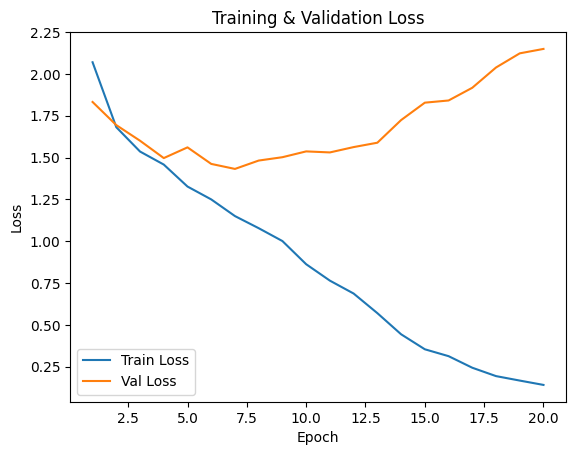

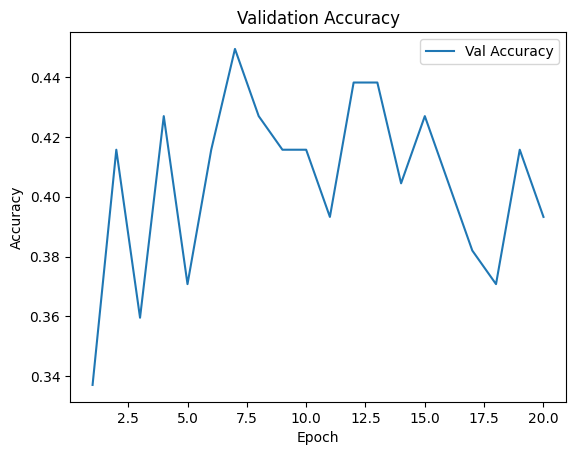

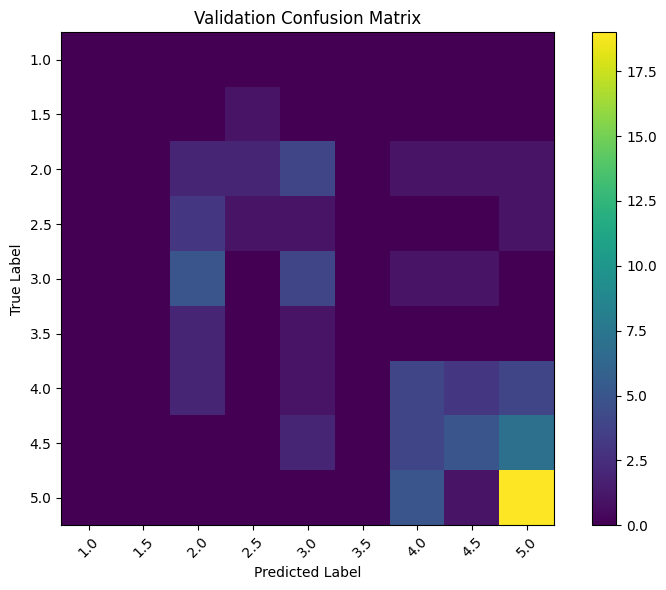

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

epochs = list(range(1, N_EPOCHS+1))

# Loss curves
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.show()

# Accuracy curve
plt.figure()
plt.plot(epochs, val_accs, label='Val Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.show()

# Confusion matrix
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for ids, mask, labels in val_loader:
        logits = model(ids.to(DEVICE), mask.to(DEVICE))
        preds  = logits.argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(LABEL_VALUES))))
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap='viridis')
plt.title('Validation Confusion Matrix')
plt.colorbar()
plt.xticks(range(len(LABEL_VALUES)), LABEL_VALUES, rotation=45)
plt.yticks(range(len(LABEL_VALUES)), LABEL_VALUES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
